# **XGBoost Baseline Model**
### Only Flight Data

In [2]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# imports for xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [3]:
flights_path = Path('/home/t1sanchez/teams/z6/data/all_flights_2018-2022.parquet')

cols = ['FlightDate', 'Year', 'Month', 'DayOfWeek', 'CRSDepTime',
       'Airline', 'Origin', 'Dest', 'Distance', 'Cancelled', 'DepDelayMinutes']

flights = pd.read_parquet(flights_path, columns=cols)
print(f'Flights DF: {len(flights):,} rows')

Flights DF: 29,193,782 rows


In [4]:
# change datatypes 
# FlightDate to datetime 
flights['FlightDate'] = pd.to_datetime(flights['FlightDate'])

# exclude covid b/c it disrupts patterns 
flights = flights[flights['Year'] != 2020]

# convert Cancelled to T/F and dep delay to numeric 
flights['Cancelled'] = flights['Cancelled'].astype(bool)
flights['DepDelayMinutes'] = pd.to_numeric(flights['DepDelayMinutes'], errors='coerce').fillna(0)

# target variable --> 3 classes 
flights['target'] = np.select(
    [flights['Cancelled'], flights['DepDelayMinutes'] >= 15],
    ['Cancelled', 'Delayed'],
    default = 'On time'
)

# get depature hour and fill na's with 12 (midday)
flights['dep_hour'] = (pd.to_numeric(flights['CRSDepTime'], errors='coerce') // 100).fillna(12).astype(int)
flights = flights[(flights['dep_hour'] >= 0) & (flights['dep_hour'] <= 23)]




In [5]:
# stratified sampling
sample = 600_000
sample_per_class = sample // 3

samples = []
for target in ['On time','Delayed','Cancelled']:
    class_df = flights[flights['target'] == target]
    n = min(len(class_df), sample_per_class)
    samples.append(class_df.sample(n=n, random_state=42))

flights = pd.concat(samples, ignore_index=True)

print(f'Sampled: {len(flights):,} rows')
print(flights['target'].value_counts())



Sampled: 600,000 rows
target
On time      200000
Delayed      200000
Cancelled    200000
Name: count, dtype: int64


In [6]:
# train/test split (80/20)

# sort by date
flights = flights.sort_values('FlightDate').reset_index(drop=True)

# get index for split
split_idx = int(len(flights) * 0.8)

# training split
train = flights.iloc[:split_idx].copy()

# test split
test = flights.iloc[split_idx:].copy()

print(f'Train: {len(train):,}')
print(f'Test: {len(test):}')

Train: 480,000
Test: 120000


In [6]:
# just flight features

# categorical
cat_features = ['Airline', 'Origin', 'Dest']

# numeric
num_features = ['Month','DayOfWeek','dep_hour','Distance']

print(f'Categorical features: {cat_features}')
print('\nNumerical features:', num_features)

Categorical features: ['Airline', 'Origin', 'Dest']

Numerical features: ['Month', 'DayOfWeek', 'dep_hour', 'Distance']


In [7]:
# feature transformations for model
# convert cat to strings for One Hot
for col in cat_features:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)
    
# numeric feats (fill missing val) and scale 
for col in num_features:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

feature_transformer = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
])

# combine features
features = cat_features + num_features

# X train/test
X_train = feature_transformer.fit_transform(train[features])

X_test = feature_transformer.transform(test[features])

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')







X_train shape: (480000, 806)
X_test shape: (120000, 806)


In [8]:
# econding targets to numeric labels --> Cancelled=0, Delayed=1, On time=2
le = LabelEncoder()

y_train = le.fit_transform(train['target'])

y_test = le.fit_transform(test['target'])

print(f'Classes: {le.classes_}')
print(f'Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}')

Classes: ['Cancelled' 'Delayed' 'On time']
Mapping: {'Cancelled': 0, 'Delayed': 1, 'On time': 2}


In [9]:
# train model 
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_Rate=0.3,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

# train_model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_Rate=0.3, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, ...)

In [10]:
# evaluate model

# predictions on test set
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
avg_f1 = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy: {acc:.3f}')
print(f'Avg f1: {avg_f1:.3f}')

Accuracy: 0.467
Avg f1: 0.464


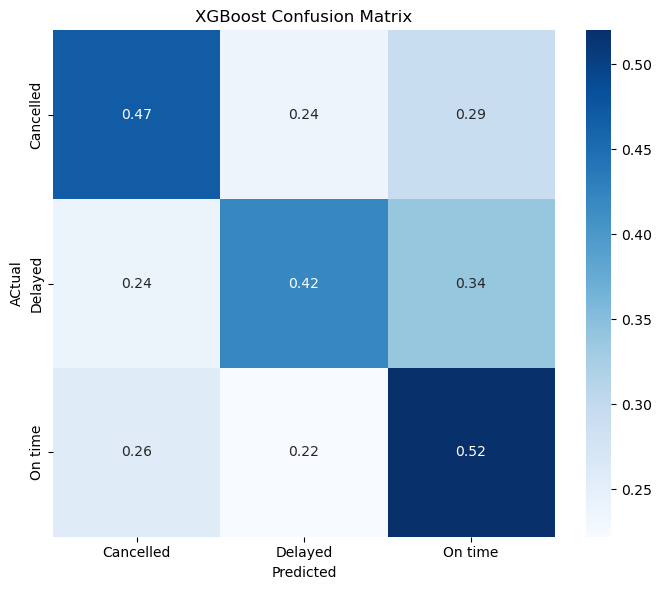

In [12]:
# confusion matrix --> see mistakes
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('ACtual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## XGBOOST on Flight + Weather Data

In [48]:
# based on progress report


In [6]:
from datetime import datetime 
import pickle
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from scipy.sparse import hstack

In [7]:
train = pd.read_parquet('/home/t1sanchez/data/splits_150k/train.parquet')
val = pd.read_parquet('/home/t1sanchez/data/splits_150k/val.parquet')
test = pd.read_parquet('/home/t1sanchez/data/splits_150k/test.parquet')

print(f'Train shape: {train.shape}')
print(f'Val shape: {val.shape}')
print(f'Test shape: {test.shape}')

Train shape: (40318, 71)
Val shape: (13440, 71)
Test shape: (13440, 71)


In [8]:
# columns/features I have
print(train.columns.tolist())

['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'CRSElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepTimeBlk', 'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup', 'year_1', 'target', 'date', 'dep_hour', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust', 'DayOfWeek_num', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'Distance_std', 'tmpf_std', 'vsby_std', 'sknt_std', 'relh_std', 'gust_s

In [9]:
# Helper Functions for
# creating extra features from progress report that are still missing 

def time_features(df):
    df['is_early_morning'] = (df['dep_hour'].isin([5,6,7])).astype(int)
    df['is_evening'] = (df['dep_hour'] >= 18).astype(int)
    return df

def seasonal_features(df):
    df['is_summer'] = (df['Month'].isin([6,7,8])).astype(int)
    df['is_holiday_season'] = (
        (df['Month'].isin([11, 12])) |
        ((df['Month'] == 1) & (df['DayofMonth'] < 7))
    ).astype(int)
    return df

def weather_thresholds(df):
    df['high_wind'] = ((df['sknt'] > 20) | (df['gust'] > 35)).astype(int)
    df['low_visibility'] = (df['vsby'] < 3).astype(int)
    return df

def precipitation_levels(df):
    df['precip_light'] = ((df['p01i'] >= 0.01) & (df['p01i'] < 0.1)).astype(int)
    df['precip_moderate'] = ((df['p01i'] >= 0.1) & (df['p01i'] < 0.5)).astype(int)
    df['precip_heavy'] = (df['p01i'] >= 0.5).astype(int)
    return df

# for the specific airlines
def airline_encoding(df, airline_stats, global_rates):
    df = df.merge(
        airline_stats[['airline_delay_rate','airline_cancel_rate','airline_on_time_rate' ]],
        left_on = 'Airline',
        right_index=True,
        how='left'
    )

    # fill missing values
    df['airline_delay_rate'] = df['airline_delay_rate'].fillna(global_rates['delay'])
    df['airline_cancel_rate'] = df['airline_cancel_rate'].fillna(global_rates['cancel'])
    df['airline_on_time_rate'] = df['airline_on_time_rate'].fillna(global_rates['on_time'])
    return df
     

In [10]:
# time of day features
train = time_features(train) 
val = time_features(val) 
test = time_features(test) 

# seasonal feats
train = seasonal_features(train)
val = seasonal_features(val)
test = seasonal_features(test)

# weather threshold feats
train = weather_thresholds(train)
val = weather_thresholds(val)
test = weather_thresholds(test)


# precipitation levels feats
train = precipitation_levels(train)
val = precipitation_levels(val)
test = precipitation_levels(test)

# airline target encoding (train)
airline_stats = train.groupby('Airline').agg({
    'target': [
        lambda x: (x == 'Delayed').mean(),
        lambda x: (x == 'Cancelled').mean(),
        lambda x: (x == 'On time').mean(),
        'count'
    ]
})

airline_stats.columns = ['delay_rate', 'cancel_rate', 'on_time_rate', 'n_flights']

# calc global rates
global_delay_rate = (train['target'] == 'Delayed').mean()
global_cancel_rate = (train['target'] == 'Cancelled').mean()
global_on_time_rate = (train['target'] == 'On time').mean()

print(f'Global delay rate: {global_delay_rate}')
print(f'Global cancel rate: {global_cancel_rate}')
print(f'Global on-time rate: {global_on_time_rate}')

# smoothing
m = 10000
airline_stats['airline_delay_rate'] = (
    (airline_stats['n_flights'] * airline_stats['delay_rate'] + m * global_delay_rate) /
    (airline_stats['n_flights'] + m)
) 

airline_stats['airline_cancel_rate'] = (
    (airline_stats['n_flights'] * airline_stats['cancel_rate'] + m * global_cancel_rate) /
    (airline_stats['n_flights'] + m)
) 

airline_stats['airline_on_time_rate'] = (
    (airline_stats['n_flights'] * airline_stats['on_time_rate'] + m * global_on_time_rate) /
    (airline_stats['n_flights'] + m)
) 

# merging datsets
global_rates = {
    'delay': global_delay_rate,
    'cancel': global_cancel_rate,
    'on_time': global_on_time_rate
}

train = airline_encoding(train, airline_stats, global_rates)
val = airline_encoding(val, airline_stats, global_rates)
test = airline_encoding(test, airline_stats, global_rates)

print(f'New train shape: {train.shape}')
print(f'New val shape: {val.shape}')
print(f'New test shape: {test.shape}')


    

Global delay rate: 0.3527208690907287
Global cancel rate: 0.03628652214891612
Global on-time rate: 0.6109926087603552
New train shape: (40318, 83)
New val shape: (13440, 83)
New test shape: (13440, 83)


In [11]:
# drop columns we don't want
exclude_cols = [
    'target',
    'FlightDate', 'date',
    'Tail_Number', 'Flight_Number_Marketing_Airline', 'Flight_Number_Operating_Airline',
    'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID',
    'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID',
    'DOT_ID_Marketing_Airline', 'DOT_ID_Operating_Airline',
    'DayOfWeek', 'month',
    'OriginCityName', 'OriginStateName',
    'DestCityName', 'DestStateName',
]

feature_cols = [col for col in train.columns if col not in exclude_cols]
print(f"Total features: {len(feature_cols)}")

# separate X and y
X_train = train[feature_cols].copy()
y_train = train['target'].copy()
X_val = val[feature_cols].copy()
y_val = val['target'].copy()
X_test = test[feature_cols].copy()
y_test = test['target'].copy()

cat_features = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_features = [col for col in X_train.columns if col not in cat_features]

print(f"Categorical: {len(cat_features)}")
print(f"Categorical features: {cat_features}")
print(f"Numerical: {len(num_features)}")

# one-hot encoding for cat feats
ohe = OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore')

X_train_cat_ohe = ohe.fit_transform(X_train[cat_features])
X_val_cat_ohe = ohe.transform(X_val[cat_features])
X_test_cat_ohe = ohe.transform(X_test[cat_features])
print('\nAfter one hot encoding categorical features:')
print(f'Categorical: {X_train_cat_ohe.shape[1]}\n')

X_train_ohe = hstack([X_train[num_features].values, X_train_cat_ohe])
X_val_ohe = hstack([X_val[num_features].values, X_val_cat_ohe])
X_test_ohe = hstack([X_test[num_features].values, X_test_cat_ohe])

print(f'Train: {X_train_ohe.shape}')
print(f'Val: {X_val_ohe.shape}')
print(f'Test: {X_test_ohe.shape}')

# get feature names for later
ohe_feat_names = ohe.get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_feat_names)


# encoding target and mapping
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Total features: 63
Categorical: 13
Categorical features: ['Airline', 'Origin', 'Dest', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'IATA_Code_Marketing_Airline', 'Operating_Airline', 'IATA_Code_Operating_Airline', 'OriginState', 'DestState', 'DepTimeBlk', 'ArrTimeBlk', 'OriginRegion']
Numerical: 50

After one hot encoding categorical features:
Categorical: 596

Train: (40318, 646)
Val: (13440, 646)
Test: (13440, 646)
Classes: {'Cancelled': 0, 'Delayed': 1, 'On time': 2}


/opt/conda/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:241: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:241: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [12]:
# adding class weights
# w = (N/(K * n))
# N=total samples; K=#classes; n=samples in each class

class_counts = np.bincount(y_train_encoded)
n_samples = len(y_train_encoded)
n_classes = len(class_counts)

class_weights = n_samples / (n_classes * class_counts)

sample_weights = class_weights[y_train_encoded]


In [13]:
# train model

xgb = XGBClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.055,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.6,
    reg_lambda=1.2,
    min_child_weight=8,
    gamma=0.15,
    max_delta_step=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    early_stopping_rounds=50
)

xgb.fit(X_train_ohe, y_train_encoded, sample_weight=sample_weights, eval_set=[(X_val_ohe, y_val_encoded)], verbose=50)

# evaluate
y_train_pred = xgb.predict(X_train_ohe)
y_val_pred = xgb.predict(X_val_ohe)
y_test_pred = xgb.predict(X_test_ohe)

train_acc = accuracy_score(y_train_encoded, y_train_pred)
val_acc = accuracy_score(y_val_encoded, y_val_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

# accuracy for split
print(f'Train accuracy: {train_acc:.4f}')
print(f'Val accuracy: {val_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')


print("\nTest set classification report:")
print(classification_report(y_test_encoded, y_test_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:1.09198
[50]	validation_0-mlogloss:0.96342
[100]	validation_0-mlogloss:0.93398
[150]	validation_0-mlogloss:0.91600
[200]	validation_0-mlogloss:0.90436
[250]	validation_0-mlogloss:0.89472
[300]	validation_0-mlogloss:0.88627
[350]	validation_0-mlogloss:0.87769
[400]	validation_0-mlogloss:0.87155
[450]	validation_0-mlogloss:0.86509
[500]	validation_0-mlogloss:0.85961
[550]	validation_0-mlogloss:0.85471
[600]	validation_0-mlogloss:0.84872
[650]	validation_0-mlogloss:0.84458
[699]	validation_0-mlogloss:0.84036
Train accuracy: 0.7024
Val accuracy: 0.6019
Test accuracy: 0.5966

Test set classification report:
              precision    recall  f1-score   support

   Cancelled       0.16      0.39      0.23       488
     Delayed       0.50      0.53      0.51      4740
     On time       0.74      0.65      0.69      8212

    accuracy                           0.60     13440
   macro avg       0.47      0.52      0.48     13440
weighted avg       0.63      0.60     

In [96]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from itertools import product
import time

In [98]:
# check params 
param_grid = {
    'n_estimators': [500, 700, 900],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.04, 0.05, 0.06, 0.07],
    'subsample': [0.7, 0.75, 0.8],
    'colsample_bytree': [0.7, 0.75, 0.8],
    'reg_alpha': [0.3, 0.5, 0.8, 1.0],
    'reg_lambda': [0.8, 1.0, 1.5, 2.0],
    'min_child_weight': [6, 8, 10],
    'gamma': [0.1, 0.15, 0.2]
}

n_tries = 50
results = []

print(f"Testing {n_tries} random combinations\n")

# picking at random 
for i in range(n_tries):
    params = {
        'n_estimators': np.random.choice(param_grid['n_estimators']),
        'max_depth': np.random.choice(param_grid['max_depth']),
        'learning_rate': np.random.choice(param_grid['learning_rate']),
        'subsample': np.random.choice(param_grid['subsample']),
        'colsample_bytree': np.random.choice(param_grid['colsample_bytree']),
        'reg_alpha': np.random.choice(param_grid['reg_alpha']),
        'reg_lambda': np.random.choice(param_grid['reg_lambda']),
        'min_child_weight': np.random.choice(param_grid['min_child_weight']),
        'gamma': np.random.choice(param_grid['gamma']),
        'max_delta_step': 1,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 50
    }
    
    print(f"[{i+1}/{n_tries}] depth={params['max_depth']}, lr={params['learning_rate']}, trees={params['n_estimators']}, alpha={params['reg_alpha']}, lambda={params['reg_lambda']}")
    
    start = time.time()
    
    # train
    xgb = XGBClassifier(**params)
    xgb.fit(X_train_ohe, y_train_encoded, 
            sample_weight=sample_weights, 
            eval_set=[(X_val_ohe, y_val_encoded)], 
            verbose=0)
    
    # evaluate
    y_test_pred = xgb.predict(X_test_ohe)
    y_train_pred = xgb.predict(X_train_ohe)
    
    train_acc = accuracy_score(y_train_encoded, y_train_pred)
    test_acc = accuracy_score(y_test_encoded, y_test_pred)
    bal_acc = balanced_accuracy_score(y_test_encoded, y_test_pred)
    
    cm = confusion_matrix(y_test_encoded, y_test_pred)
    canc_recall = cm[0, 0] / cm[0].sum()
    delay_recall = cm[1, 1] / cm[1].sum()
    ontime_recall = cm[2, 2] / cm[2].sum()
    
    elapsed = time.time() - start
    
    results.append({
        'iter': i+1,
        'test_acc': test_acc,
        'bal_acc': bal_acc,
        'canc_recall': canc_recall,
        'delay_recall': delay_recall,
        'ontime_recall': ontime_recall,
        'gap': train_acc - test_acc,
        **params
    })
    
    print(f"  Test: {test_acc:.4f}, Balanced: {bal_acc:.4f}, Cancelled: {canc_recall:.2%}, Gap: {train_acc-test_acc:.4f} ({elapsed:.1f}s)\n")

# convert to df
df = pd.DataFrame(results)

# show top models
print("\nTop 10 by test accuracy:")
print(df.sort_values('test_acc', ascending=False)[['iter', 'test_acc', 'bal_acc', 'canc_recall', 'gap', 'max_depth', 'learning_rate', 'n_estimators']].head(10))

print("\nTop 10 by balanced accuracy:")
print(df.sort_values('bal_acc', ascending=False)[['iter', 'test_acc', 'bal_acc', 'canc_recall', 'gap', 'max_depth', 'learning_rate', 'n_estimators']].head(10))

print("\nTop 10 by cancelled recall:")
print(df.sort_values('canc_recall', ascending=False)[['iter', 'test_acc', 'bal_acc', 'canc_recall', 'gap', 'max_depth', 'learning_rate', 'n_estimators']].head(10))

# best overall
df['score'] = df['test_acc'] + df['bal_acc']
best = df.sort_values('score', ascending=False).iloc[0]

print(f"\nBest overall (iteration {int(best['iter'])}):")
print(f"Test acc: {best['test_acc']:.4f}")
print(f"Balanced acc: {best['bal_acc']:.4f}")
print(f"Cancelled recall: {best['canc_recall']:.2%}")
print(f"Delayed recall: {best['delay_recall']:.2%}")
print(f"Gap: {best['gap']:.4f}")
print(f"\nParams: depth={int(best['max_depth'])}, lr={best['learning_rate']}, trees={int(best['n_estimators'])}, alpha={best['reg_alpha']}, lambda={best['reg_lambda']}, min_child={int(best['min_child_weight'])}, gamma={best['gamma']}")

Testing 50 random combinations

[1/50] depth=5, lr=0.05, trees=700, alpha=1.0, lambda=1.0
  Test: 0.5909, Balanced: 0.5215, Cancelled: 39.96%, Gap: 0.1005 (19.8s)

[2/50] depth=6, lr=0.07, trees=700, alpha=1.0, lambda=0.8
  Test: 0.6113, Balanced: 0.5076, Cancelled: 30.74%, Gap: 0.1725 (20.7s)

[3/50] depth=4, lr=0.07, trees=700, alpha=0.8, lambda=1.5
  Test: 0.5819, Balanced: 0.5214, Cancelled: 42.01%, Gap: 0.0836 (19.4s)

[4/50] depth=5, lr=0.06, trees=700, alpha=0.8, lambda=2.0
  Test: 0.5977, Balanced: 0.5213, Cancelled: 38.32%, Gap: 0.1117 (20.0s)

[5/50] depth=4, lr=0.05, trees=700, alpha=0.8, lambda=1.5
  Test: 0.5722, Balanced: 0.5198, Cancelled: 43.65%, Gap: 0.0701 (19.1s)

[6/50] depth=5, lr=0.05, trees=500, alpha=0.5, lambda=2.0
  Test: 0.5880, Balanced: 0.5245, Cancelled: 41.80%, Gap: 0.0824 (14.2s)

[7/50] depth=4, lr=0.04, trees=500, alpha=0.8, lambda=2.0
  Test: 0.5640, Balanced: 0.5259, Cancelled: 47.75%, Gap: 0.0475 (13.7s)

[8/50] depth=4, lr=0.06, trees=700, alpha=1.

In [14]:
# choosing #7 iteration bc it has less overfitting and still good accuracy and recall
# train model

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.7,
    colsample_bytree=0.75,
    reg_alpha=0.8,
    reg_lambda=2.0,
    min_child_weight=6,
    gamma=0.1,
    max_delta_step=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    early_stopping_rounds=50
)

xgb.fit(X_train_ohe, y_train_encoded, sample_weight=sample_weights, eval_set=[(X_val_ohe, y_val_encoded)], verbose=50)

# evaluate
y_train_pred = xgb.predict(X_train_ohe)
y_val_pred = xgb.predict(X_val_ohe)
y_test_pred = xgb.predict(X_test_ohe)

train_acc = accuracy_score(y_train_encoded, y_train_pred)
val_acc = accuracy_score(y_val_encoded, y_val_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

# accuracy for split
print(f'Train accuracy: {train_acc:.4f}')
print(f'Val accuracy: {val_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')


print("\nTest set classification report:")
print(classification_report(y_test_encoded, y_test_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:1.09458
[50]	validation_0-mlogloss:0.99412
[100]	validation_0-mlogloss:0.96571
[150]	validation_0-mlogloss:0.95042
[200]	validation_0-mlogloss:0.93998
[250]	validation_0-mlogloss:0.93245
[300]	validation_0-mlogloss:0.92619
[350]	validation_0-mlogloss:0.91973
[400]	validation_0-mlogloss:0.91487
[450]	validation_0-mlogloss:0.91013
[499]	validation_0-mlogloss:0.90621
Train accuracy: 0.6127
Val accuracy: 0.5710
Test accuracy: 0.5638

Test set classification report:
              precision    recall  f1-score   support

   Cancelled       0.13      0.47      0.20       488
     Delayed       0.49      0.48      0.48      4740
     On time       0.73      0.62      0.67      8212

    accuracy                           0.56     13440
   macro avg       0.45      0.52      0.45     13440
weighted avg       0.62      0.56      0.59     13440



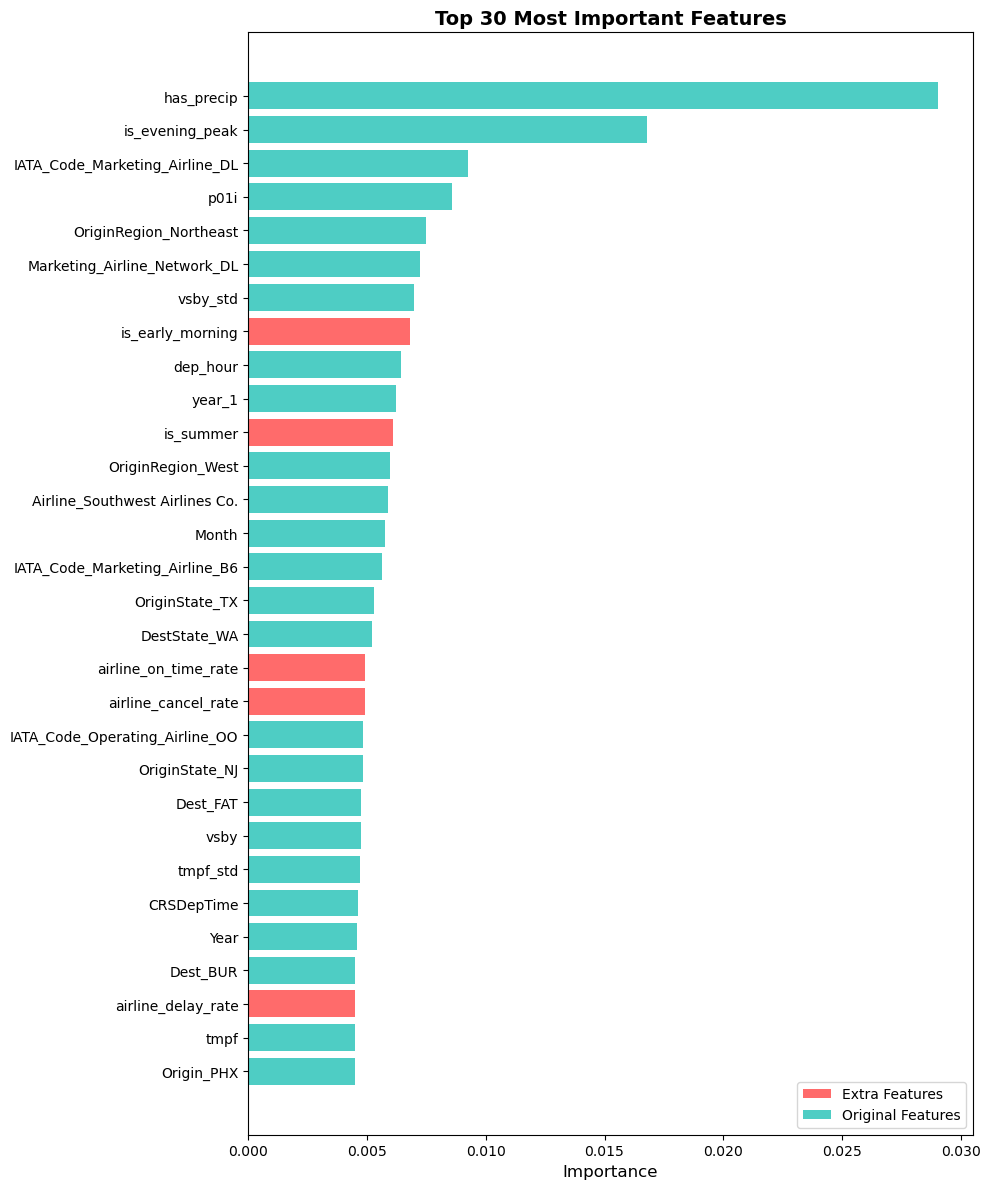

In [18]:
# feature importance
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

# top 30 features
top_30 = feature_importance.head(30)

# later addition to engineered features
extra_features = [
    'is_early_morning', 'is_evening',
    'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility',
    'precip_light', 'precip_moderate', 'precip_heavy',
    'airline_delay_rate', 'airline_cancel_rate', 'airline_on_time_rate'
]

# make Arely features one color and extra features different color
colors = ['#ff6b6b' if feat in extra_features else '#4ecdc4' for feat in top_30['feature']]

fig, ax = plt.subplots(figsize=(10,12))
bars = ax.barh(range(len(top_30)), top_30['importance'], color=colors)
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['feature'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 30 Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# legend
legend_elements = [
    Patch(facecolor='#ff6b6b', label='Extra Features'),
    Patch(facecolor='#4ecdc4', label='Original Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


# Adding more features to see if it helps
----
### Other relationships to explore:
1. Does delay rate vary by route?
2. Is there a relationship between bad whether and time?